# Control Técnico 3 · Series temporales y forecasting

**Curso:** Análisis de Datos  
**Programa:** Magíster en Data Science · Universidad del Desarrollo  
**Código:** MDSC3S112-1  

**Estudiante:** Luciano Hernández

**Fecha:** 2026-09-11

### Propósito
Aplicar los conceptos fundamentales de **análisis de series temporales y forecasting** desarrollados en el Módulo 04.

A diferencia del Laboratorio Práctico 4, en este control se espera que el estudiante avance desde una serie temporal previamente explorada y preparada hacia su **modelamiento y pronóstico**, tomando decisiones justificadas a partir de la estructura observada en los datos.

La evaluación se centrará principalmente en el **razonamiento temporal, la interpretación y la validación**, y no únicamente en la ejecución de código.

## 1. Exploración y diagnóstico de la serie

Realiza una exploración breve que permita identificar:

- comportamiento general de la serie;
- tendencia;
- posible estacionalidad;
- frecuencia temporal;
- características relevantes para el modelamiento.

No es necesario repetir todo el proceso de preparación realizado en el Laboratorio 4.

In [1]:
# Importación de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [2]:
timeSeries = pd.read_csv("month_sells_clean.csv").assign(
    fecha = pd.to_datetime(pd.read_csv("month_sells_clean.csv")["fecha"])
).set_index("fecha")

For Values:
	ADF Statistic: 0.005234626893373795
	p-value: 95.89628510729511%
	Critical Values:
 		1%: -3.5443688564814813
		5%: -2.9110731481481484
		10%: -2.5931902777777776


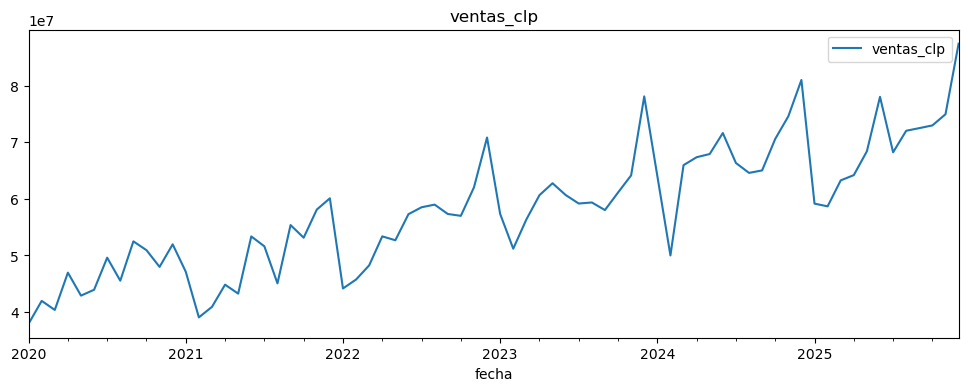

For Differences of Order 1:
	ADF Statistic: -8.210709213111846
	p-value: 6.830728508929333e-11%
	Critical Values:
 		1%: -3.5443688564814813
		5%: -2.9110731481481484
		10%: -2.5931902777777776


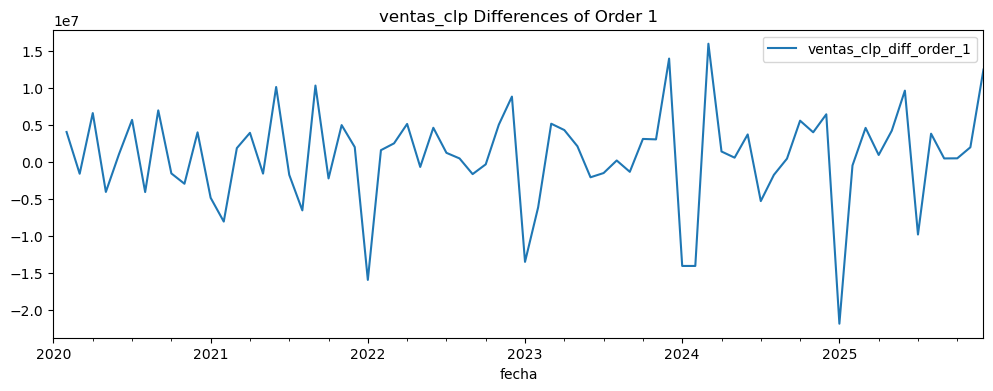

Autocorrelation


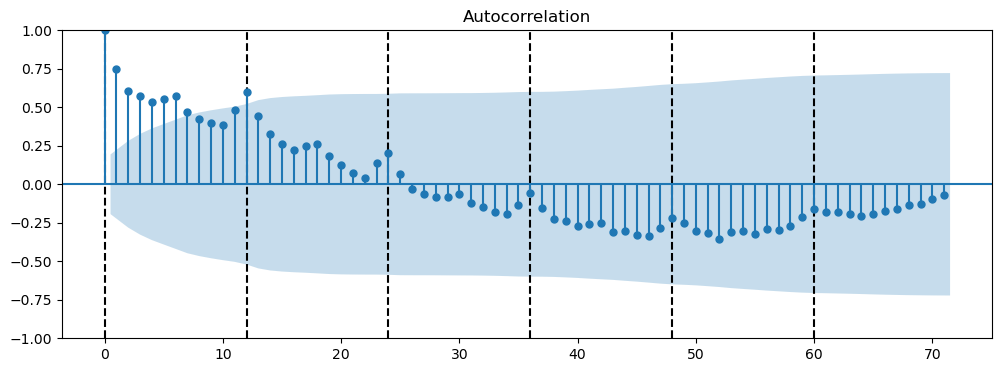

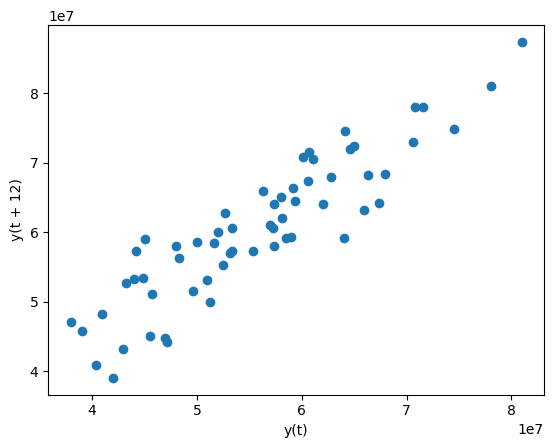

In [10]:
timeSeriesWithDiff = timeSeries.assign(
    ventas_clp_diff_order_0 = timeSeries["ventas_clp"]
)
adfResult = {}
adfResult[0] = adfuller(timeSeriesWithDiff["ventas_clp_diff_order_0"])
print("For Values:")
print(f"\tADF Statistic: {adfResult[0][0]}")
print(f"\tp-value: {adfResult[0][1] * 100}%")
print("\tCritical Values:\n", "\n".join([ f"\t\t{k}: {v}" for k, v in adfResult[0][4].items() ]))
fig, ax = plt.subplots(figsize = (12, 4))
timeSeriesWithDiff.plot(y = "ventas_clp", ax = ax)
plt.title("ventas_clp")
plt.show()
i = 0
while adfResult[i][1] > 0.05:
    i += 1
    timeSeriesWithDiff[f"ventas_clp_diff_order_{i}"] = timeSeriesWithDiff[f"ventas_clp_diff_order_{i - 1}"].diff()
    adfResult[i] = adfuller(timeSeriesWithDiff[f"ventas_clp_diff_order_{i}"].dropna())
    print(f"For Differences of Order {i}:")
    print(f"\tADF Statistic: {adfResult[i][0]}")
    print(f"\tp-value: {adfResult[i][1] * 100}%")
    print("\tCritical Values:\n", "\n".join([ f"\t\t{k}: {v}" for k, v in adfResult[i][4].items() ]))
    fig, ax = plt.subplots(figsize = (12, 4))
    timeSeriesWithDiff.plot(y = f"ventas_clp_diff_order_{i}", ax = ax)
    plt.title(f"ventas_clp Differences of Order {i}")
    plt.show()

print("Autocorrelation")

fig, ax = plt.subplots(figsize = (12, 4))
for i in range(0, timeSeries.shape[0] - 1, 12):
    plt.axvline(x = i, color = "black", linestyle = "--")
plot_acf(timeSeries["ventas_clp"], lags = timeSeries.shape[0] - 1, ax = ax, alpha = 0.1)
plt.show()

pd.plotting.lag_plot(timeSeries["ventas_clp"], lag = 12)
plt.show()

## 2. Estacionariedad

Evalúa si la serie presenta evidencia de no estacionariedad.

Utiliza herramientas revisadas en el módulo, considerando la **prueba ADF** y la inspección visual cuando corresponda.

Si es necesario, justifica la aplicación de una diferenciación.

## 3. Autocorrelación y selección del modelo

Analiza la estructura temporal mediante herramientas como:

- ACF;
- PACF.

A partir de la evidencia disponible, propone y justifica un modelo temporal apropiado.

Se espera una aplicación acotada de **ARIMA o SARIMA**, según las características de la serie.

No es necesario realizar una búsqueda exhaustiva de modelos.

## 4. Forecasting

Genera un pronóstico para un horizonte definido.

El resultado debe incluir, cuando corresponda:

- valores pronosticados;
- intervalo de predicción;
- visualización del forecast.

Explica qué representa el horizonte elegido en el contexto del problema.

## 5. Validación

Evalúa el desempeño del modelo respetando el **orden temporal de los datos**.

Compara los valores observados con los pronosticados y utiliza al menos una métrica de error revisada en el módulo, como:

- MAE;
- RMSE.

Interpreta el resultado obtenido.

## 6. Conclusiones y limitaciones

Responde la pregunta planteada a partir de los resultados obtenidos.

Identifica además las principales limitaciones del pronóstico, considerando aspectos como:

- horizonte de predicción;
- comportamiento histórico;
- cambios estructurales;
- incertidumbre;

calidad o longitud de la serie.